# Cargar librerias y direccion de los datos

In [1]:
import pandas as pd
import duckdb
import os
os.environ["OMP_NUM_THREADS"] = "1" 
import importlib
from pathlib import Path
import helpers

importlib.reload(helpers)
from helpers import encontrar_y_cargar, procesar_medidores, ejecutar_pipeline_limpieza

# Iniciar base de datos DuckDB
con = duckdb.connect('data.db')

# Limpieza preventiva: Borramos lo anterior para asegurar que los nuevos filtros actúen
con.execute("DROP TABLE IF EXISTS data_final_cleaned CASCADE")
con.execute("DROP TABLE IF EXISTS data_año CASCADE")
con.execute("DROP VIEW IF EXISTS raw_data_medidores CASCADE")

# EJECUTAR PIPELINE 
encontrar_y_cargar(con, "data")
procesar_medidores(con) 
ejecutar_pipeline_limpieza(con)

# CONFIGURACIÓN SQL MAGIC
%load_ext sql
%config SqlMagic.autopandas = True
%sql con
data_año_cleaned = con.execute("SELECT * FROM data_final_cleaned").df()

Archivo detectado y cargado como 'raw_data_medidores': Mediciones.parquet
 Procesamiento de integridad y actividad completado: 'data_año' lista.
Pipeline de limpieza completado: Tabla 'data_final_cleaned' lista.


# Limpieza de datos

# DataFrame de trabajo

In [2]:
# Definir la variable global de Grupos
n_clusters = 3

# el nmero de cluster se escogio en base al metodo del codo

In [3]:
# PROMEDIO POR PULSO EN EL AÑO SEPARADO POR TIPO DE CURVA Y MEDIDOR
data_año_cleaned_grouped = data_año_cleaned.groupby(['mRID', 'hhmm','tipo_curva'], observed=True).agg(
    {'P_kW': 'mean'}).reset_index()

In [4]:
# PASAR LOS DATOS A UNA MATRIZ
X_Verano = data_año_cleaned_grouped[data_año_cleaned_grouped['tipo_curva'] == 'Verano'].pivot(
    index='mRID',
    columns='hhmm',
    values='P_kW').copy()
# extracción de los indices de los medidores de verano
index_verano = X_Verano.index

X_Invierno = data_año_cleaned_grouped[data_año_cleaned_grouped['tipo_curva'] == 'Invierno'].pivot(
    index='mRID',
    columns='hhmm',
    values='P_kW').copy()
# extracción de los indices de los medidores de invierno
index_invierno = X_Invierno.index

In [5]:
# # Convertir los datos a un array de numpy
    # tiene formato de (numero de medidores, numero de pulsos)
X_Verano = X_Verano.to_numpy()      
X_Invierno = X_Invierno.to_numpy()

In [6]:
# Escalar los datos
from sklearn.preprocessing import MinMaxScaler
scaler_verano = MinMaxScaler()
scaler_invierno = MinMaxScaler()

X_Verano_scaled = scaler_verano.fit_transform(X_Verano.T)
X_Invierno_scaled = scaler_invierno.fit_transform(X_Invierno.T)

In [7]:
from sklearn.cluster import KMeans

# Crear el modelo K-means para Verano
kmeans_verano = KMeans(n_clusters = n_clusters)
kmeans_verano.fit(X_Verano_scaled.T)
labels_verano = kmeans_verano.labels_
centroids_verano = kmeans_verano.cluster_centers_

# Crear el modelo K-means para Invierno
kmeans_invierno = KMeans(n_clusters = n_clusters)
kmeans_invierno.fit(X_Invierno_scaled.T)
labels_invierno = kmeans_invierno.labels_
centroids_invierno = kmeans_invierno.cluster_centers_

In [8]:
#UNIR LOS CLUSTER A LOS DATOS DE LOS MEDIDORES
from datetime import datetime, timedelta
# Crear una lista de tiempos en formato %H:%M con intervalos de 15 minutos
base_time = datetime.strptime('00:00', '%H:%M')
time_intervals = [(base_time + timedelta(minutes=15 * i)).strftime('%H:%M') for i in range(96)]

In [9]:
#VERANO
X_data_verano = pd.DataFrame(X_Verano_scaled).T
X_data_verano['cluster'] = labels_verano
X_data_verano['meter_id'] = index_verano

In [10]:
X_data_verano_pivot = X_data_verano.melt(
    id_vars = ['cluster','meter_id'],var_name = 'hhmm', value_name = 'P_kW_scaled'
)
display(X_data_verano_pivot)

,cluster,meter_id,hhmm,P_kW_scaled
0,1,Bowie_236,0,0.461331
1,2,Bowie_364,0,0.568107
2,2,Bowie_408,0,0.532466
3,2,Bowie_487,0,0.318585
4,1,Bowie_502,0,0.638966
...,...,...,...,...
13723,2,Tom_Iorkeke_677,95,0.790082
13724,1,Tom_Iorkeke_74,95,0.742879
13725,2,Tom_Iorkeke_84,95,0.896218
13726,0,Tom_Iorkeke_901,95,0.579501


In [11]:
X_data_verano_pivot.sort_values(by = ['meter_id','hhmm'], inplace = True)
display(X_data_verano_pivot)

,cluster,meter_id,hhmm,P_kW_scaled
0,1,Bowie_236,0,0.461331
143,1,Bowie_236,1,0.378717
286,1,Bowie_236,2,0.320385
429,1,Bowie_236,3,0.274266
572,1,Bowie_236,4,0.228106
...,...,...,...,...
13155,0,Tom_Iorkeke_904,91,0.896805
13298,0,Tom_Iorkeke_904,92,0.846317
13441,0,Tom_Iorkeke_904,93,0.780510
13584,0,Tom_Iorkeke_904,94,0.729192


In [12]:
# Mapear los valores de hhmm a los tiempos en formato %H:%M
X_data_verano_pivot['hhmm'] = X_data_verano_pivot['hhmm'].map(dict(enumerate(time_intervals)))
display(X_data_verano_pivot)

,cluster,meter_id,hhmm,P_kW_scaled
0,1,Bowie_236,00:00,0.461331
143,1,Bowie_236,00:15,0.378717
286,1,Bowie_236,00:30,0.320385
429,1,Bowie_236,00:45,0.274266
572,1,Bowie_236,01:00,0.228106
...,...,...,...,...
13155,0,Tom_Iorkeke_904,22:45,0.896805
13298,0,Tom_Iorkeke_904,23:00,0.846317
13441,0,Tom_Iorkeke_904,23:15,0.780510
13584,0,Tom_Iorkeke_904,23:30,0.729192


In [13]:
#INVIERNO
X_data_invierno = pd.DataFrame(X_Invierno_scaled).T
X_data_invierno['cluster'] = labels_invierno
X_data_invierno['meter_id'] = index_invierno

X_data_invierno_pivot = X_data_invierno.melt(
    id_vars=['cluster', 'meter_id'], var_name='hhmm', value_name='P_kW_scaled'
    )
X_data_invierno_pivot.sort_values(by=['meter_id', 'hhmm'], inplace=True)
# Mapear los valores de hhmm a los tiempos en formato %H:%M
X_data_invierno_pivot['hhmm'] = X_data_invierno_pivot['hhmm'].map(dict(enumerate(time_intervals)))

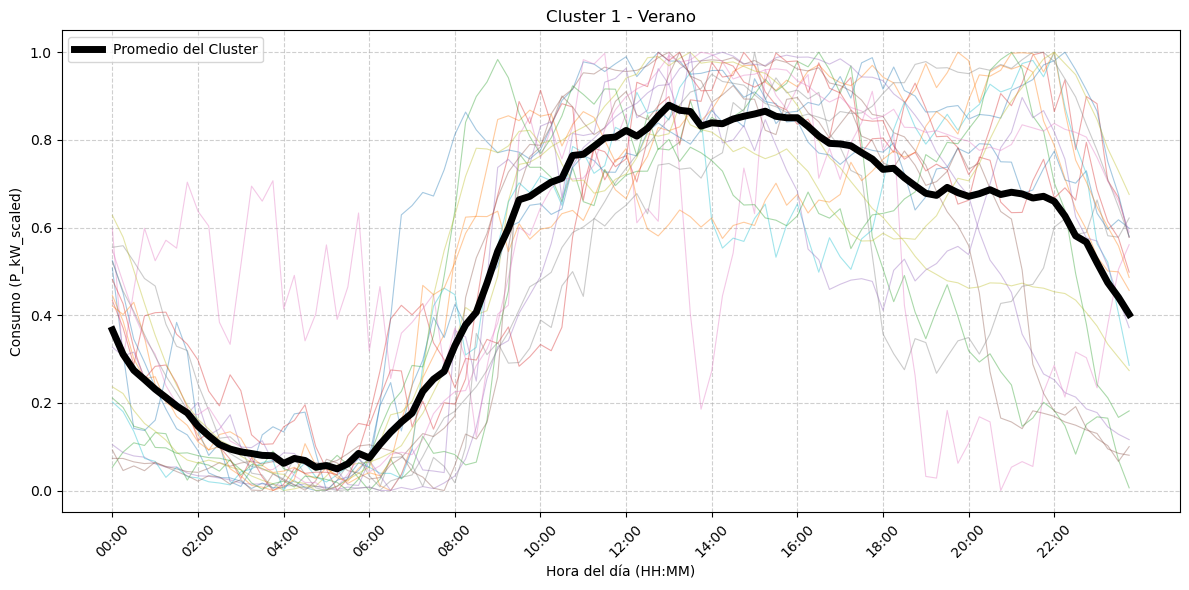

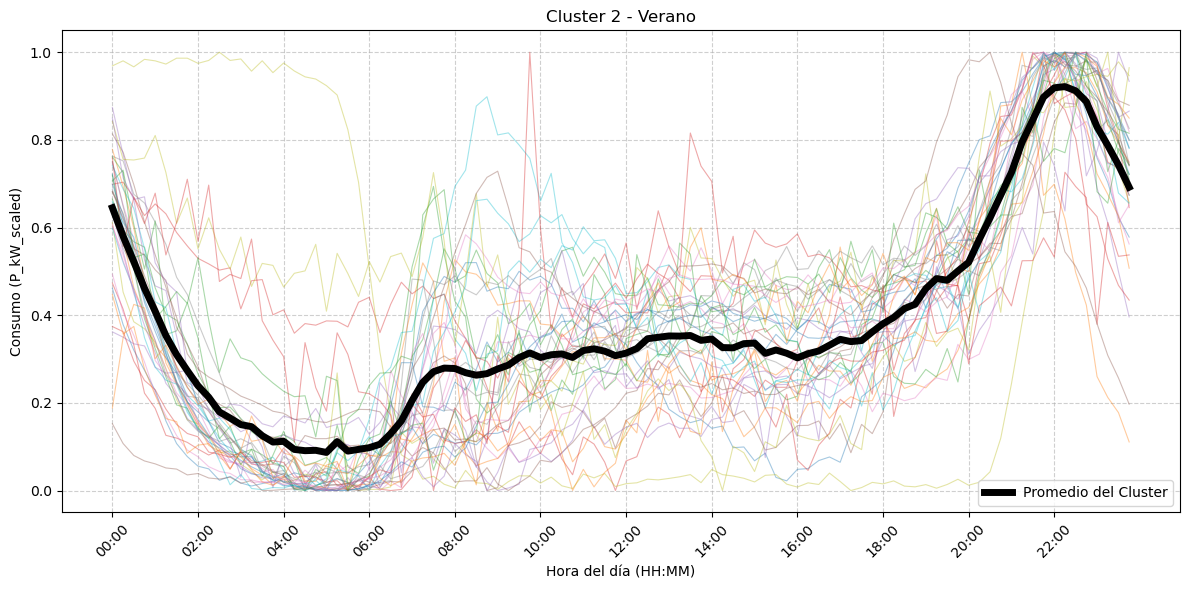

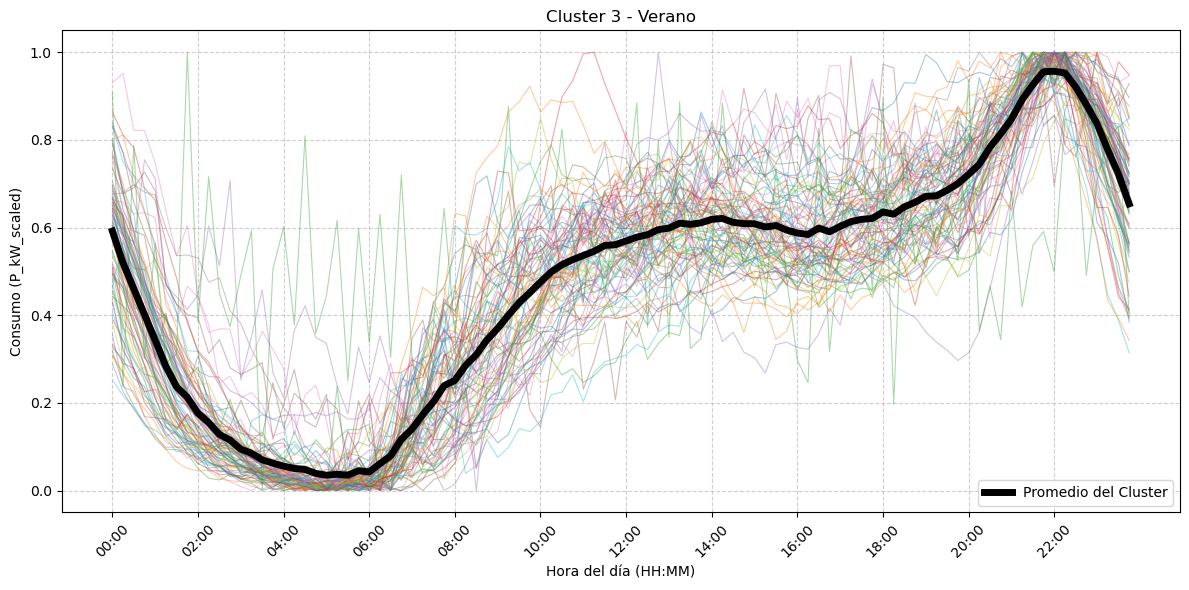

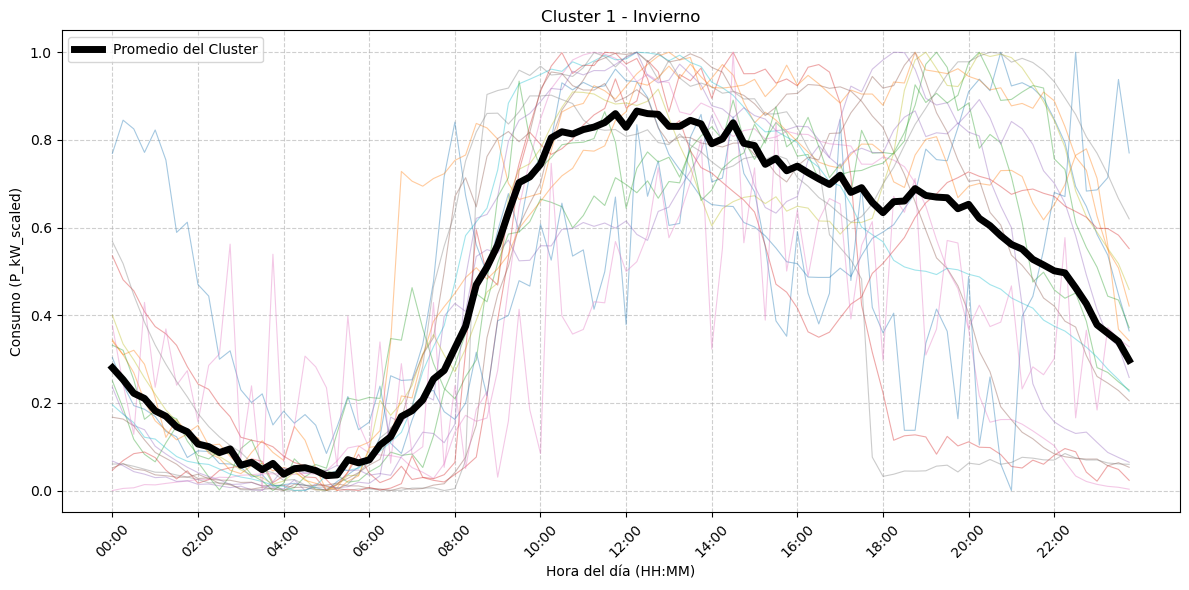

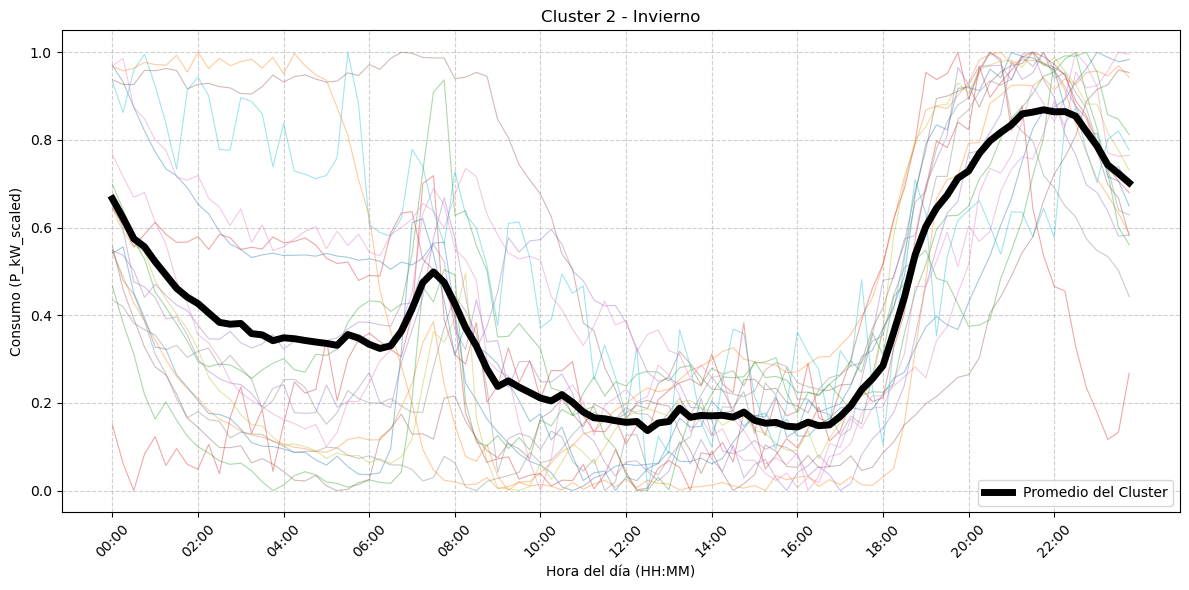

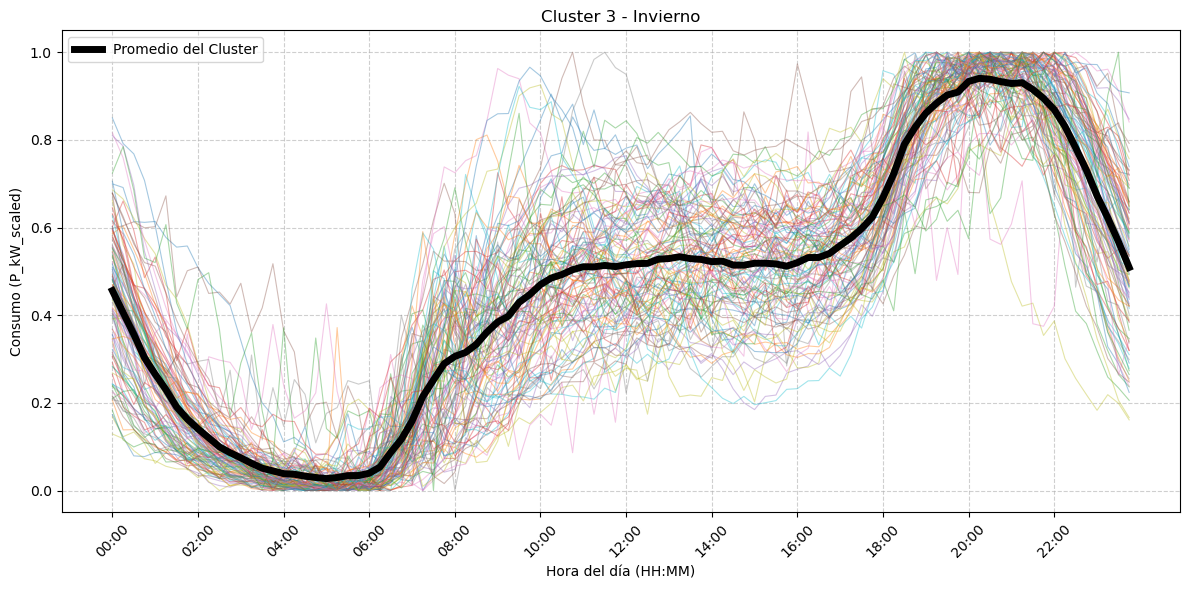

In [17]:
import GraphicsHelper
import importlib

# 1. Fuerza a Python a leer el archivo desde el disco nuevamente
importlib.reload(GraphicsHelper)

from GraphicsHelper import generar_graficos_estaticos

# Ahora usas la versión estática
generar_graficos_estaticos(X_data_verano_pivot, n_clusters, "Verano")
generar_graficos_estaticos(X_data_invierno_pivot, n_clusters, "Invierno")

In [ ]:
import GraphicsHelper
import importlib
importlib.reload(GraphicsHelper)
from GraphicsHelper import generar_graficos_interactivos

generar_graficos_interactivos(X_data_verano_pivot, n_clusters, "Verano")
generar_graficos_interactivos(X_data_invierno_pivot, n_clusters, "Invierno")

## Codo para ver el número de clusters

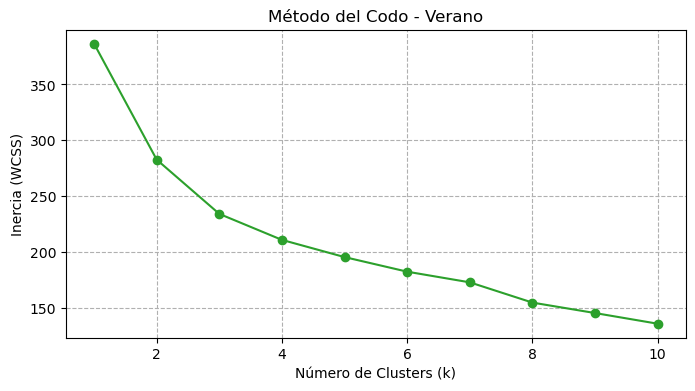

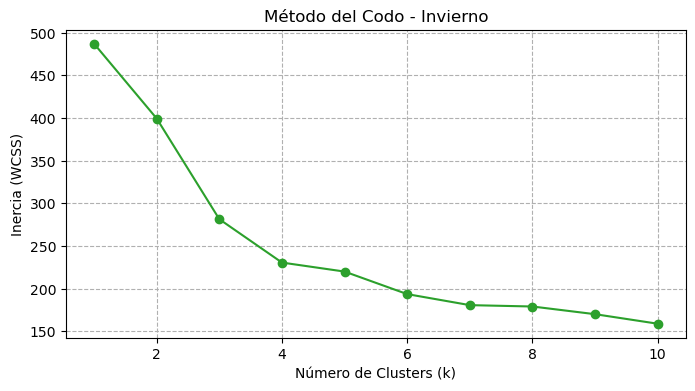

In [30]:
from ElbowMethod import graficar_codo
# Llamada para Verano
graficar_codo(X_Verano_scaled, "Verano")

# Llamada para Invierno
graficar_codo(X_Invierno_scaled, "Invierno")